In [1]:
# import scanpy as sc
# import anndata as ad
# import numpy as np
# import pandas as pd

# adata = sc.read_h5ad('data/snRNA_data/RGC.h5ad')
# adata.X = adata.layers['counts'].copy()
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# genes = ['Ryr2', 'Atp2a2']
# expr_data = pd.DataFrame(
#     adata[:, genes].X.toarray() if hasattr(adata[:, genes].X, 'toarray') else adata[:, genes].X,
#     columns=genes,
#     index=adata.obs_names
# )

# plot_df = pd.concat([expr_data, adata.obs[['condition']]], axis=1)

# long_df = plot_df.melt(id_vars=['condition'], value_vars=genes, 
#                        var_name='gene', value_name='expression')

# long_df.to_csv("data/snRNA_data/ER_genes_expression.csv", index=False)

In [1]:
library(ggplot2)
library(ggbreak)
library(ggpubr)
library(dplyr)

ggbreak v0.1.7 Learn more at https://yulab-smu.top/



If you use ggbreak in published research, please cite the following
paper:

S Xu, M Chen, T Feng, L Zhan, L Zhou, G Yu. Use ggbreak to effectively
utilize plotting space to deal with large datasets and outliers.
Frontiers in Genetics. 2021, 12:774846. doi: 10.3389/fgene.2021.774846



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
df <- read.csv("data/snRNA_data/ER_genes_expression.csv")

In [3]:
df_summary <- df %>%
  group_by(condition, gene) %>%
  summarise(
    mean_expr = mean(expression),
    sd_expr = sd(expression),
    n = n(),
    se_expr = sd_expr / sqrt(n),
    .groups = 'drop'
  )

In [4]:
df_summary$condition <- c('Ct','Ct','2w','2w','4w','4w','8w','8w')

In [5]:
df_summary$gene <- factor(df_summary$gene,levels=c('Ryr2','Atp2a2'))
df_summary$condition <- factor(df_summary$condition,levels=c('Ct','2w','4w','8w'))

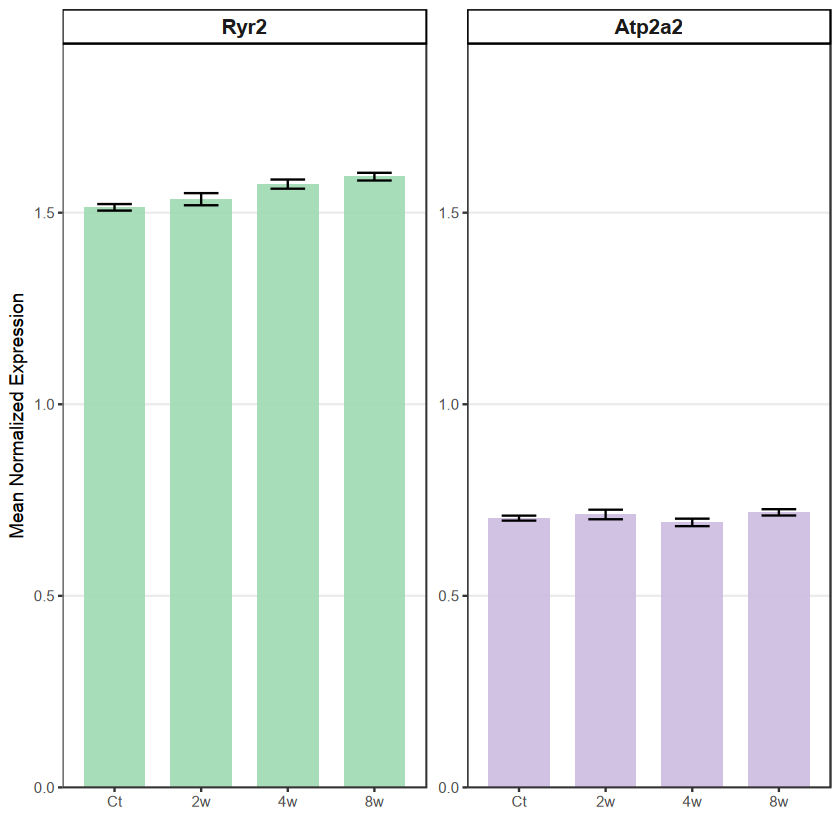

In [6]:
max_y <- max(df_summary$mean_expr + df_summary$se_expr, na.rm = TRUE)

ggplot(df_summary, aes(x = condition, y = mean_expr, fill = gene)) +
  facet_wrap(~gene, ncol = 2, scales = "free_y") +
  geom_bar(stat = "identity", width = 0.7, alpha = 0.9) +
  geom_errorbar(aes(ymin = mean_expr - se_expr, ymax = mean_expr + se_expr), 
                width = 0.4) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1)), limits = c(0, max_y * 1.1)) +
  scale_fill_manual(values = c("Ryr2" = "#9DD9B1", "Atp2a2" = "#CCBAE0")) +
  theme_bw() +
  labs(
    x = " ",
    y = "Mean Normalized Expression",
    fill = ""
  ) +
  theme(
    legend.position = "none",
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "white", color = "black"),
    strip.text = element_text(face = "bold", size = 12)
  ) 